# Sudoku CV Solver — Training Notebook

This notebook covers:
1. Dataset overview & statistics
2. YOLOv11 fine-tuning for grid/cell detection
3. CNN training for digit recognition
4. Evaluation & benchmark comparison


In [8]:
# ─── Setup ────────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

# Ensure both project root (`scripts/`) and source package dir (`src/`) are importable
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'scripts').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'

for p in (PROJECT_ROOT, SRC_DIR):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2

DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)
print('Setup OK')

Setup OK


## 1. Dataset Overview

easy    :  162 images
medium  :    0 images
hard    :    0 images
expert  :    0 images


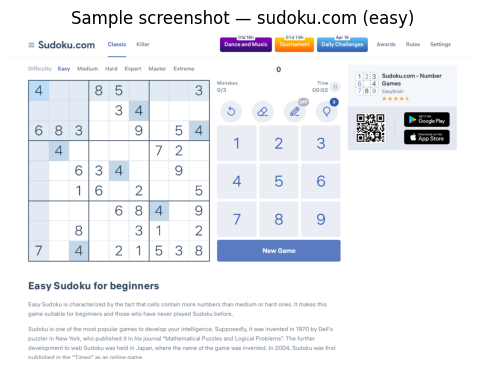

In [9]:
# Count collected screenshots per difficulty
for diff in ['easy', 'medium', 'hard', 'expert']:
    imgs = list((DATA_DIR / 'raw' / diff).glob('*.png'))
    print(f'{diff:8s}: {len(imgs):4d} images')

# Show a sample
sample = cv2.imread(str(list((DATA_DIR / 'raw' / 'easy').glob('*.png'))[0]))
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
plt.title('Sample screenshot — sudoku.com (easy)')
plt.axis('off')
plt.show()

## 2. YOLOv11 Fine-tuning

In [ ]:
from scripts.train_yolo import train

# Ensure relative paths inside training script resolve from project root
os.chdir(PROJECT_ROOT)

# Fine-tune YOLOv11-nano (fastest, ~2.6M params)
results_nano = train(
    model_variant='yolo11n.pt',
    epochs=50,
    imgsz=640,
    batch=16,
)
print('Training complete')

New https://pypi.org/project/ultralytics/8.4.39 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.38  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\annotated\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.1, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.5, multi_scale

In [ ]:
# Plot training curves
import pandas as pd

results_csv = PROJECT_ROOT / 'runs' / 'detect' / 'sudoku' / 'results.csv'
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    df.plot('epoch', ['train/box_loss', 'val/box_loss'], ax=axes[0], title='Box Loss')
    df.plot('epoch', ['metrics/precision(B)', 'metrics/recall(B)'], ax=axes[1], title='Precision / Recall')
    df.plot('epoch', ['metrics/mAP50(B)', 'metrics/mAP50-95(B)'], ax=axes[2], title='mAP')
    plt.tight_layout()
    plt.savefig('yolo_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Final mAP@0.5: {df["metrics/mAP50(B)"].iloc[-1]:.4f}')

## 3. CNN Digit Classifier Training

In [ ]:
# GPU/CUDA diagnostic before CNN training
import torch

print(f'torch version: {torch.__version__}')
print(f'cuda available: {torch.cuda.is_available()}')
print(f'cuda build: {torch.version.cuda}')

if torch.cuda.is_available():
    cnn_device = 'cuda:0'
    print(f'Using GPU: {torch.cuda.get_device_name(0)}')
else:
    cnn_device = 'cpu'
    print('Using CPU for CNN training')
    if torch.version.cuda is None:
        print('PyTorch is CPU-only. Reinstall CUDA-enabled torch to use your GPU.')

torch version: 2.11.0+cu128
cuda available: True
cuda build: 12.8
Using GPU: NVIDIA GeForce RTX 3070 Laptop GPU


In [ ]:
from ocr.cnn_model import train_cnn

train_dir = DATA_DIR / 'processed' / 'train'
val_dir = DATA_DIR / 'processed' / 'val'
output_path = MODELS_DIR / 'cnn_digits.pth'

if not train_dir.exists() or not val_dir.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Run: "
        "python scripts/prepare_processed_data.py --difficulty easy medium hard --label-methods easyocr"
    )

best_acc = train_cnn(
    train_dir=str(train_dir),
    val_dir=str(val_dir),
    output_path=str(output_path),
    epochs=20,
    batch_size=64,
    device=cnn_device,
 )
print(f'Best validation accuracy: {best_acc:.4f}')

Best validation accuracy: 1.0000


## 4. Benchmark — Recognition Methods Comparison

In [ ]:
# Evaluate all 4 methods on 50 held-out cell images
import json
import shutil
from pathlib import Path
from ocr.digit_recognizer import DigitRecognizer

TEST_CELLS_DIR = DATA_DIR / 'processed' / 'test'
TEMPLATE_DIR = PROJECT_ROOT / 'data' / 'templates'
CNN_MODEL_PATH = MODELS_DIR / 'cnn_digits.pth'

def resolve_tesseract_cmd():
    """Return a working tesseract executable path or None."""
    # 1) Normal PATH resolution
    cmd = shutil.which('tesseract')
    if cmd:
        return cmd

    # 2) Common Windows install locations
    candidates = [
        Path('C:/Program Files/Tesseract-OCR/tesseract.exe'),
        Path('C:/Program Files (x86)/Tesseract-OCR/tesseract.exe'),
    ]
    for p in candidates:
        if p.exists():
            return str(p)

    return None

def configure_tesseract_backend():
    """Configure pytesseract to a concrete executable when available."""
    cmd = resolve_tesseract_cmd()
    if not cmd:
        return None

    try:
        import pytesseract
        pytesseract.pytesseract.tesseract_cmd = cmd
    except Exception:
        return None

    return cmd

def backend_availability(method):
    """Return (available: bool, reason: str)."""
    if method == 'tesseract':
        cmd = configure_tesseract_backend()
        if cmd is None:
            return False, 'tesseract binary not found in PATH or default Windows install directories'
        return True, f'ok ({cmd})'

    if method == 'template':
        if not TEMPLATE_DIR.exists():
            return False, f"template directory missing: {TEMPLATE_DIR}"
        template_files = list(TEMPLATE_DIR.glob('*.png'))
        if not template_files:
            return False, f"no template images found in: {TEMPLATE_DIR}"
        return True, f"{len(template_files)} template file(s) found"

    if method == 'cnn':
        if not CNN_MODEL_PATH.exists():
            return False, f"CNN model missing: {CNN_MODEL_PATH}"
        return True, 'ok'

    # easyocr (and any future backend) availability is validated by constructor
    return True, 'ok'

def build_recognizer(method):
    """Construct recognizer with explicit paths for path-sensitive backends."""
    if method == 'template':
        return DigitRecognizer(method='template', template_dir=str(TEMPLATE_DIR))
    if method == 'cnn':
        return DigitRecognizer(method='cnn', model_path=str(CNN_MODEL_PATH))
    return DigitRecognizer(method=method)

def evaluate_method(method, test_dir, sample_size=50, seed=42):
    rec = build_recognizer(method)
    correct, total, total_ms = 0, 0, 0.0

    # Build a deterministic pool of labeled test images
    all_samples = []
    for digit_dir in sorted(test_dir.iterdir()):
        if not digit_dir.is_dir():
            continue
        gt = int(digit_dir.name)
        for img_path in digit_dir.glob('*.png'):
            all_samples.append((gt, img_path))

    if not all_samples:
        raise FileNotFoundError(f'No test images found under: {test_dir}')

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(all_samples), size=min(sample_size, len(all_samples)), replace=False)
    sampled = [all_samples[i] for i in idx]

    for gt, img_path in sampled:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        t0 = time.perf_counter()
        pred = rec._backend.predict_cell(img)
        total_ms += (time.perf_counter() - t0) * 1000
        correct += (pred == gt)
        total += 1

    return {
        'status': 'ok',
        'accuracy': correct / total if total else 0,
        'avg_ms_per_cell': total_ms / total if total else 0,
        'evaluated_cells': total,
        'requested_cells': min(sample_size, len(all_samples)),
    }

methods = ['easyocr', 'tesseract', 'template', 'cnn']
bench = {}

for m in methods:
    print(f'Evaluating {m}...')
    available, reason = backend_availability(m)
    if not available:
        print(f'  SKIPPED: {reason}')
        bench[m] = {'status': 'skipped', 'reason': reason}
        continue

    try:
        bench[m] = evaluate_method(m, TEST_CELLS_DIR, sample_size=50, seed=42)
        print(
            f'  acc={bench[m]["accuracy"]:.3f}  '
            f'{bench[m]["avg_ms_per_cell"]:.1f} ms/cell  '
            f'n={bench[m]["evaluated_cells"]}'
        )
    except Exception as e:
        print(f'  FAILED: {e}')
        bench[m] = {'status': 'failed', 'error': str(e)}

print('\nRaw benchmark JSON:')
print(json.dumps(bench, indent=2))

print('\nSetup hints:')
if bench.get('tesseract', {}).get('status') == 'skipped':
    print(' - Install Tesseract OCR and add it to PATH (see README).')
if bench.get('template', {}).get('status') == 'skipped':
    print(' - Generate templates with: python scripts/extract_templates.py')
if bench.get('cnn', {}).get('status') == 'skipped':
    print(' - Train CNN model by running section 3 in this notebook.')

Evaluating easyocr...
  acc=1.000  10.7 ms/cell  n=50
Evaluating tesseract...
  acc=0.760  118.8 ms/cell  n=50
Evaluating template...
  acc=0.500  1.5 ms/cell  n=50
Evaluating cnn...
  acc=0.100  1.0 ms/cell  n=50

Raw benchmark JSON:
{
  "easyocr": {
    "status": "ok",
    "accuracy": 1.0,
    "avg_ms_per_cell": 10.70949799996015,
    "evaluated_cells": 50,
    "requested_cells": 50
  },
  "tesseract": {
    "status": "ok",
    "accuracy": 0.76,
    "avg_ms_per_cell": 118.83372199990845,
    "evaluated_cells": 50,
    "requested_cells": 50
  },
  "template": {
    "status": "ok",
    "accuracy": 0.5,
    "avg_ms_per_cell": 1.4549419999457314,
    "evaluated_cells": 50,
    "requested_cells": 50
  },
  "cnn": {
    "status": "ok",
    "accuracy": 0.1,
    "avg_ms_per_cell": 1.023406000022078,
    "evaluated_cells": 50,
    "requested_cells": 50
  }
}

Setup hints:


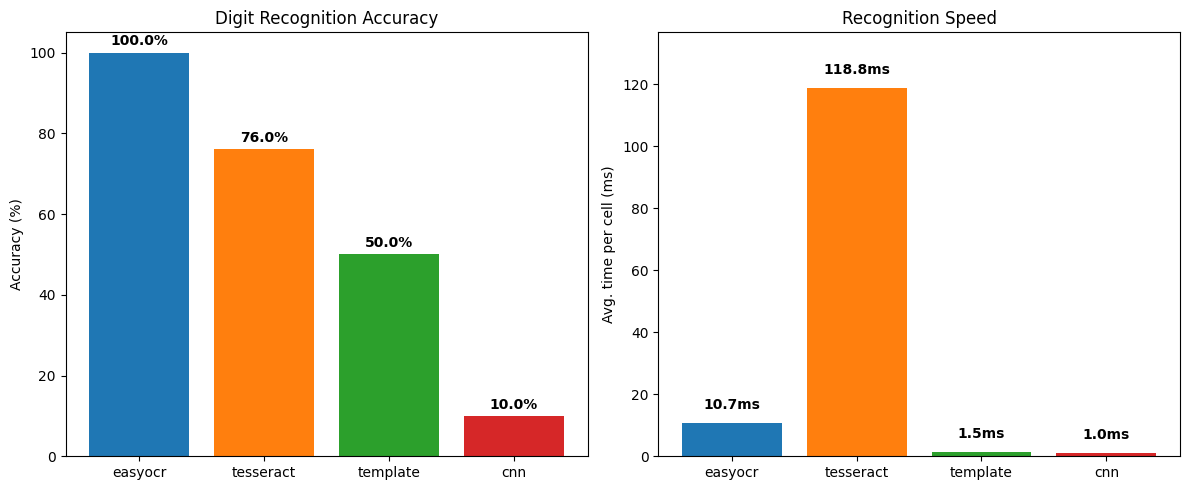


Method         Accuracy    ms/cell    ms/grid
----------------------------------------------
easyocr          100.0%       10.7      867.5
tesseract         76.0%      118.8     9625.5
template          50.0%        1.5      117.9
cnn               10.0%        1.0       82.9

Method status:
 - easyocr: ok
 - tesseract: ok
 - template: ok
 - cnn: ok


In [ ]:
# Visualize comparison
valid = {k: v for k, v in bench.items() if v.get('status') == 'ok'}

if not valid:
    print('No successful benchmark results to plot.')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    methods_v = list(valid.keys())
    accuracies = [valid[m]['accuracy'] * 100 for m in methods_v]
    speeds = [valid[m]['avg_ms_per_cell'] for m in methods_v]

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    bars1 = ax1.bar(methods_v, accuracies, color=colors[:len(methods_v)])
    y_min = min(0.0, min(accuracies) - 5.0)
    y_max = max(100.0, max(accuracies) + 5.0)
    ax1.set_ylim(y_min, y_max)
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Digit Recognition Accuracy')
    for bar, val in zip(bars1, accuracies):
        text_y = val + max(0.5, (y_max - y_min) * 0.01)
        ax1.text(bar.get_x() + bar.get_width()/2, text_y,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

    bars2 = ax2.bar(methods_v, speeds, color=colors[:len(methods_v)])
    speed_max = max(speeds) if speeds else 1.0
    ax2.set_ylim(0, max(1.0, speed_max * 1.15))
    ax2.set_ylabel('Avg. time per cell (ms)')
    ax2.set_title('Recognition Speed')
    for bar, val in zip(bars2, speeds):
        text_y = val + max(0.02, speed_max * 0.03)
        ax2.text(bar.get_x() + bar.get_width()/2, text_y,
                 f'{val:.1f}ms', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print table
    print(f'\n{"Method":<12} {"Accuracy":>10} {"ms/cell":>10} {"ms/grid":>10}')
    print('-' * 46)
    for m in methods_v:
        acc = valid[m]['accuracy'] * 100
        ms = valid[m]['avg_ms_per_cell']
        print(f'{m:<12} {acc:>9.1f}% {ms:>10.1f} {ms*81:>10.1f}')

# Print method status summary (ok/skipped/failed)
print('\nMethod status:')
for method, result in bench.items():
    status = result.get('status', 'unknown')
    if status == 'ok':
        print(f' - {method}: ok')
    elif status == 'skipped':
        print(f" - {method}: skipped ({result.get('reason', 'no reason provided')})")
    elif status == 'failed':
        print(f" - {method}: failed ({result.get('error', 'no error message')})")
    else:
        print(f' - {method}: {status}')